In [114]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import numpy as np
import os

plt.rcParams.update({'font.family': 'Times New Roman', 'mathtext.fontset': 'cm'})

In [115]:
times = [0, ]
areas = [0, ]
areas_sd = [0, ]
for file in os.listdir():
    if '.csv' in file:
        data = pd.read_csv(file)
        time = int(file.split('sec')[0])
        mean = data.iloc[-4, -4]
        sd = data.iloc[-3, -4]
        times.append(time)
        areas.append(mean)
        areas_sd.append(sd)

times_sd = [0, ] + [1] * (len(times) - 1)

times, areas, areas_sd, times_sd = np.array(times), np.array(areas), np.array(areas_sd), np.array(times_sd)

In [116]:
print(times, areas)

[ 0 15 25  2  5] [0.    0.204 0.24  0.004 0.058]


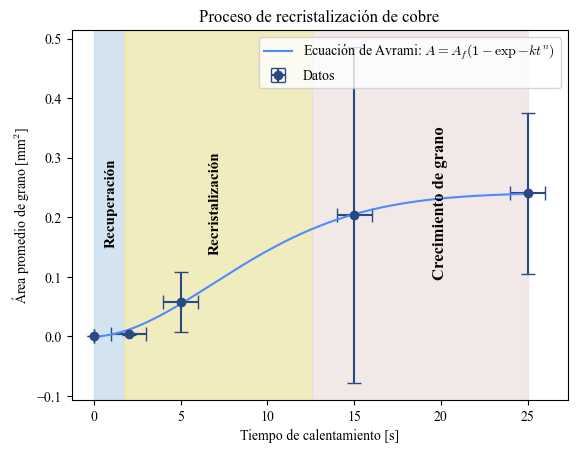

In [157]:
fig, ax = plt.subplots()
ax.errorbar(times, areas, yerr=areas_sd, xerr=times_sd, fmt='o', capsize=5, label='Datos', color='#294985')

fit = lambda t, D, k, n: D * (1 - np.exp(-k * t**n))
derivative_fit = lambda t, D, k, n: D * k * n * t**(n - 1) * np.exp(-k * t**n)
p0 = [0.25, 0.004, 2.0] 
popt, pcov = curve_fit(fit, times, areas, p0=p0)

times_ = np.linspace(times[0], 25, 10**3)
areas_ = fit(times_, *popt)

average_index = np.argmin(np.abs(areas_ - (np.max(areas_) + np.min(areas_)) / 2))
average_time = times_[average_index]
average_area = areas_[average_index]
derivative_value = derivative_fit(average_time, *popt)
filter = np.abs(average_area + derivative_value * (times_ - average_time) - areas_) < 0.01
min_time = np.min(times_[filter])
max_time = np.max(times_[filter])

ax.plot(times_, areas_, label='Ecuación de Avrami: $A = A_f (1 - \exp{-k t^n})$', color='#4e8bff')

ax.axvspan(0, min_time, color="#c8dcec", alpha=0.8)
ax.axvspan(min_time, max_time, color="#eee8ad", alpha=0.8)
ax.axvspan(max_time, 25, color="#eadcdb", alpha=0.65)

ax.text(
    1, 0.224, "Recuperación",
    rotation=90, ha="center", va="center",
    fontsize=11, fontweight="bold"
)
ax.text(
    7, 0.224, "Recristalización",
    rotation=90, ha="center", va="center",
    fontsize=11, fontweight="bold"
)
ax.text(
    20, 0.224, "Crecimiento de grano",
    rotation=90, ha="center", va="center",
    fontsize=12, fontweight="bold"
)

plt.legend()
ax.set(title="Proceso de recristalización de cobre", xlabel='Tiempo de calentamiento [s]', ylabel='Área promedio de grano [mm$^2$]')

plt.savefig("recrys.png", dpi=300)